In [1]:
!pip install textblob

In [2]:
from textblob import TextBlob
import pandas as pd
import urllib.request

In [4]:
url = "https://raw.githubusercontent.com/justmarkham/DAT8/master/data/chipotle.tsv"
urllib.request.urlretrieve(url, "chipotle.tsv")

df = pd.read_csv("chipotle.tsv", sep="\t")
df.head()

,order_id,quantity,item_name,choice_description,item_price
0,1,1,Chips and Fresh Tomato Salsa,NaN,$2.39
1,1,1,Izze,[Clementine],$3.39
2,1,1,Nantucket Nectar,[Apple],$3.39
3,1,1,Chips and Tomatillo-Green Chili Salsa,NaN,$2.39
4,2,2,Chicken Bowl,"[Tomatillo-Red Chili Salsa (Hot), [Black Beans...",$16.98


In [5]:
df["text"] = df["item_name"] + " " + df["choice_description"].fillna("")

In [6]:
def get_sentiment(text):
    analysis = TextBlob(text)
    return analysis.sentiment.polarity

df["sentiment_score"] = df["text"].apply(get_sentiment)

In [7]:
def get_label(score):
    if score > 0:
        return "Positive"
    elif score < 0:
        return "Negative"
    else:
        return "Neutral"

df["sentiment"] = df["sentiment_score"].apply(get_label)

In [8]:
df[["text", "sentiment_score", "sentiment"]].head(10)

,text,sentiment_score,sentiment
0,Chips and Fresh Tomato Salsa,0.300000,Positive
1,Izze [Clementine],0.000000,Neutral
2,Nantucket Nectar [Apple],0.000000,Neutral
3,Chips and Tomatillo-Green Chili Salsa,0.000000,Neutral
4,"Chicken Bowl [Tomatillo-Red Chili Salsa (Hot),...",-0.166667,Negative
5,"Chicken Bowl [Fresh Tomato Salsa (Mild), [Rice...",-0.029167,Negative
6,Side of Chips,0.000000,Neutral
7,"Steak Burrito [Tomatillo Red Chili Salsa, [Faj...",-0.105556,Negative
8,"Steak Soft Tacos [Tomatillo Green Chili Salsa,...",-0.083333,Negative
9,"Steak Burrito [Fresh Tomato Salsa, [Rice, Blac...",-0.005556,Negative


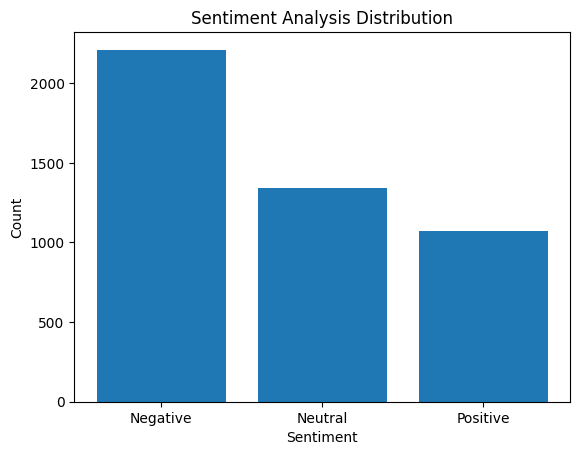

In [9]:
import matplotlib.pyplot as plt

sentiment_counts = df["sentiment"].value_counts()

plt.figure()
plt.bar(sentiment_counts.index, sentiment_counts.values)

plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.title("Sentiment Analysis Distribution")

plt.show()

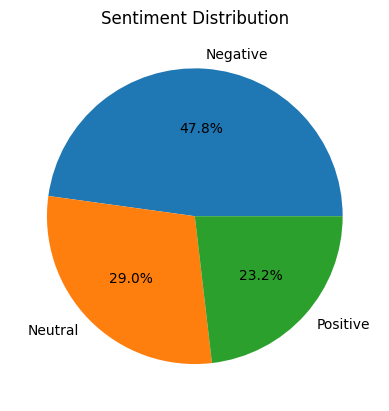

In [10]:
plt.figure()
plt.pie(sentiment_counts.values, labels=sentiment_counts.index, autopct='%1.1f%%')

plt.title("Sentiment Distribution")
plt.show()